# Disclaimer

This notebook has been left unattended and a bit self-supervised by claude. please reach out to nearchos if something is unclear or seems sketchy. The refined versions were shared earlier in the rebuttals notebook.


In [1]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import numpy as np

from utils import load_data, calculate_stability_metrics, bootstrap_confidence_intervals, stratified_bootstrap_ci, bootstrap_relative_instability, compare_ranking_methodologies, analyze_correlations, plot_model_metrics_2x2, plot_model_cost_metrics_2x2, plot_scores_with_ci
verbose = False

# Strategies


In [ ]:
mode = "Strategy"
col="Score"

# Strategy order
strategy_order=[
    "react",
    "tot_bfs",
    "foa"
]

df = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode=mode, columns=["Temperature"])

In [3]:
df1 = df[df.Temperature==0.00].copy()
df2 = df[df.Temperature==0.35].copy()
df3 = df[df.Temperature==0.70].copy()

dfs = [df1, df2, df3]

for df in dfs:
    print(df.shape)

(90, 5)
(90, 5)
(90, 5)


In [4]:
tables = []
for df in dfs:
    
    # 2. Stability Analysis (Variance of Z-Scores)
    stability_df = calculate_stability_metrics(df, mode=mode, col=col)
    
    # 3. Confidence Intervals (Bootstrap)
    ci_df = bootstrap_confidence_intervals(df, mode=mode, col=col)
    
    # Run Stratified Bootstrap
    strat_ci_df = stratified_bootstrap_ci(df, mode=mode ,col=col)
    
    # Run Evaluation
    rel_instability_df = bootstrap_relative_instability(df, mode=mode, col=col)

    # --- Compile Tables ---
    raw_means = df.groupby(mode)[col].mean()
    sorted_strategies = raw_means.sort_values(ascending=False).index

    # Table 1: Performance
    table1 = pd.DataFrame({
        f"{col} (Avg)": raw_means,
        "95% CI (Stratified)": strat_ci_df["Strat_CI_Formatted"]
    }).reindex(sorted_strategies)

    # Table 2: Relative Instability
    instability_pct = (rel_instability_df["Rel_Instability_Mean"] * 100).round(2).astype(str) + "%"
    table2 = pd.DataFrame({
        "Rel. Run Instability": instability_pct,
        "95% CI (Instability)": rel_instability_df["Rel_Instability_CI"]
    }).reindex(sorted_strategies)

    # Table 3: Noise Metrics (Z-based)
    table3 = pd.DataFrame({
        "Global Noise (Z-Var)": stability_df["Global_Noise"],
        "Run Noise (Z-Var)": stability_df["Run_Noise"]
    }).reindex(sorted_strategies)

    table = pd.concat([table1, table2, table3], axis=1)
    tables.append(table)

Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...
Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...
Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...


In [5]:
result = pd.concat(tables, axis=1, keys=['T=0.00', 'T=0.35', 'T=0.70'])
result = result.swaplevel(axis=1).reindex(columns=tables[0].columns, level=0)
result

Score (Avg)                  95% CI (Stratified)                    \
              T=0.00    T=0.35 T=0.70              T=0.00            T=0.35   
Strategy                                                                      
foa         0.373374  0.422409  0.532    [0.3493, 0.4059]  [0.3924, 0.4524]   
tot_bfs     0.330892  0.401697  0.460    [0.2974, 0.3587]  [0.3706, 0.4306]   
react       0.091101  0.103013  0.130    [0.0708, 0.1133]  [0.0872, 0.1199]   

                           Rel. Run Instability                  \
                    T=0.70               T=0.00  T=0.35  T=0.70   
Strategy                                                          
foa       [0.4733, 0.5733]                7.99%    8.7%   9.88%   
tot_bfs   [0.4133, 0.5067]               10.61%   8.63%  17.07%   
react     [0.1133, 0.1533]               42.25%  58.41%  54.34%   

         95% CI (Instability)                                  \
                       T=0.00          T=0.35          T=0.70   
Strategy                                                        
foa            [0.022, 0.166]  [0.025, 0.182]  [0.022, 0.270]   
tot_bfs        [0.016, 0.191]  [0.023, 0.202]  [0.022, 0.313]   
react          [0.228, 1.381]  [0.344, 1.918]  [0.339, 1.380]   

         Global Noise (Z-Var)                     Run Noise (Z-Var)            \
                       T=0.00    T=0.35    T=0.70            T=0.00    T=0.35   
Strategy                                                                        
foa                  0.916862  0.820833  0.659914          0.457686  0.347804   
tot_bfs              0.316798  0.228019  0.483781          0.272258  0.239998   
react                0.655755  0.804818  0.822241          0.301067  0.349350   

                    
            T=0.70  
Strategy            
foa       0.569275  
tot_bfs   0.348110  
react     0.343760

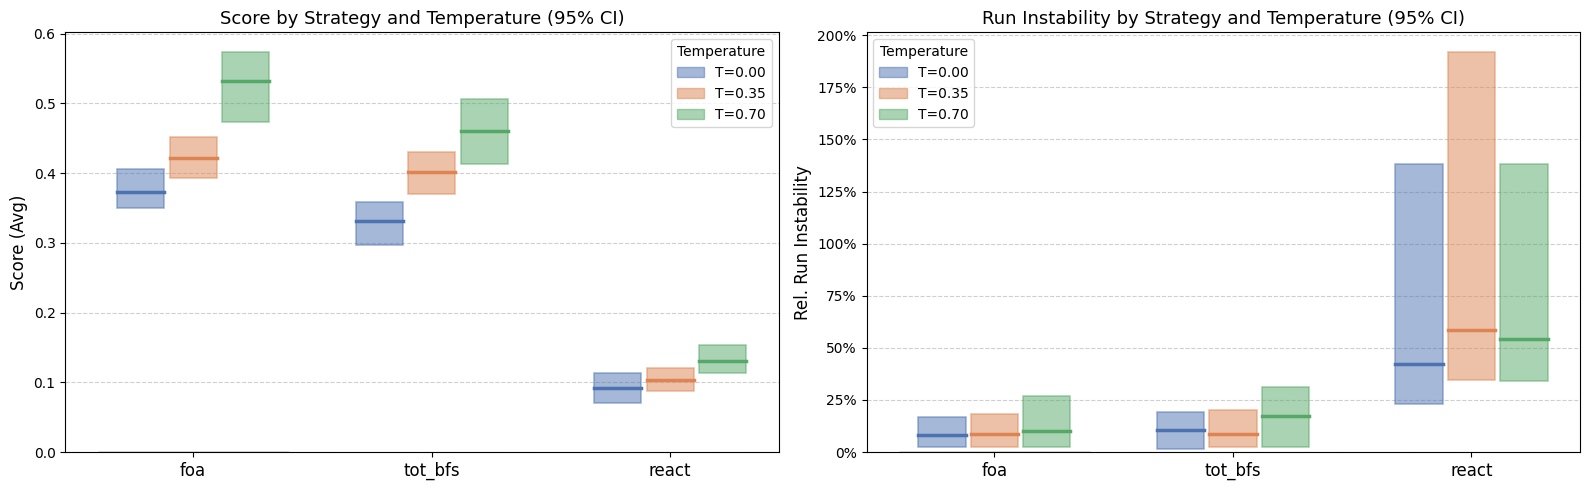

In [6]:
plot_scores_with_ci(result, "temp_strategies.pdf")

/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/876560011.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,


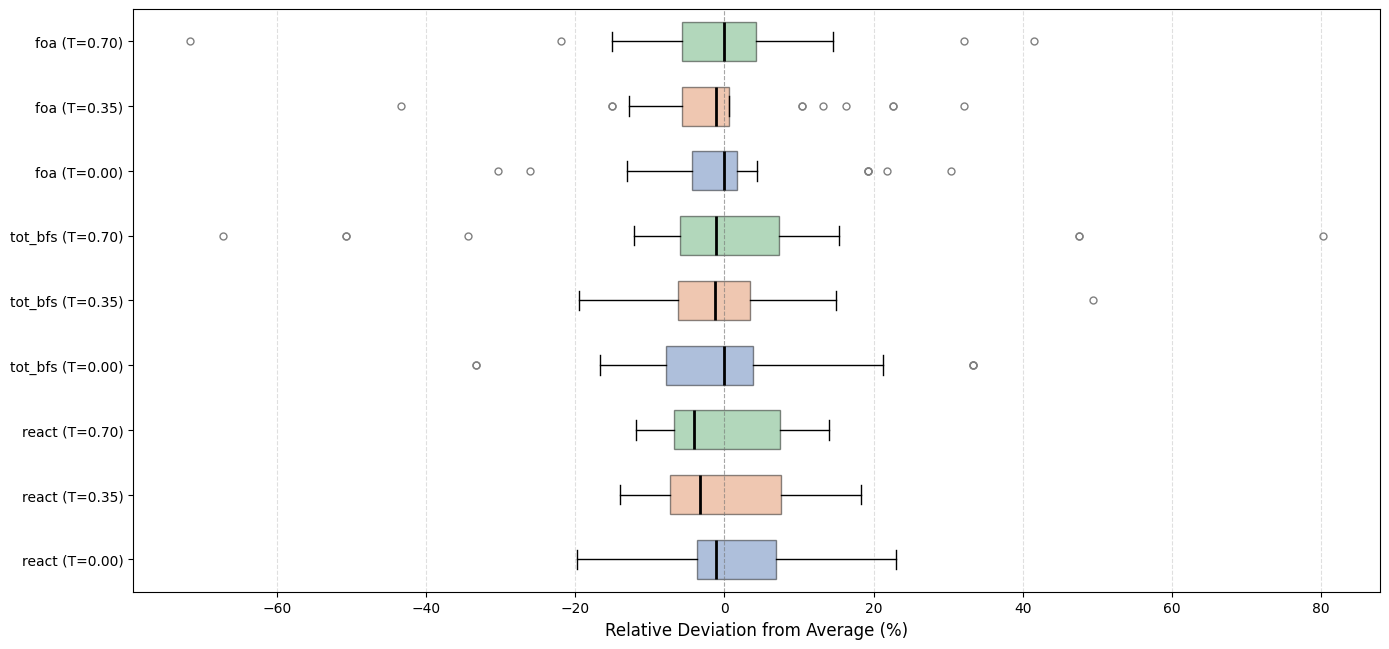

In [ ]:
import matplotlib.pyplot as plt

# Reload the raw data (the variable 'df' was overwritten in the loop above)
df_strat = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Temperature"])

# Filter out groups with near-zero mean (relative deviation is meaningless there)
group_means = df_strat.groupby(["Strategy", "Temperature", "Benchmark"])["Score"].transform("mean")
df_strat = df_strat[group_means > 0.05].copy()

# Compute relative deviation from average (%) per strategy-temperature-benchmark group
df_strat["Rel_Dev"] = df_strat.groupby(["Strategy", "Temperature", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

# Build labels and collect data for box plot
temps = [0.00, 0.35, 0.70]
strategies = ["react", "tot_bfs", "foa"]
labels, data = [], []
for s in strategies:
    for t in temps:
        mask = (df_strat["Strategy"] == s) & (df_strat["Temperature"] == t)
        data.append(df_strat.loc[mask, "Rel_Dev"].values)
        labels.append(f"{s} (T={t:.2f})")

colors_map = {0.00: '#4C72B0', 0.35: '#DD8452', 0.70: '#55A868'}
box_colors = [colors_map[t] for s in strategies for t in temps]

fig, ax = plt.subplots(figsize=(14, 0.6 * len(labels) + 1.2))
bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                widths=0.6,
                flierprops=dict(marker='o', markerfacecolor='none', markeredgecolor='grey', markersize=5))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_xlabel("Relative Deviation from Average (%)", fontsize=12)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("temp_strategies_reldev.pdf")
plt.show()

/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/2048806980.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/2048806980.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/2048806980.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1d

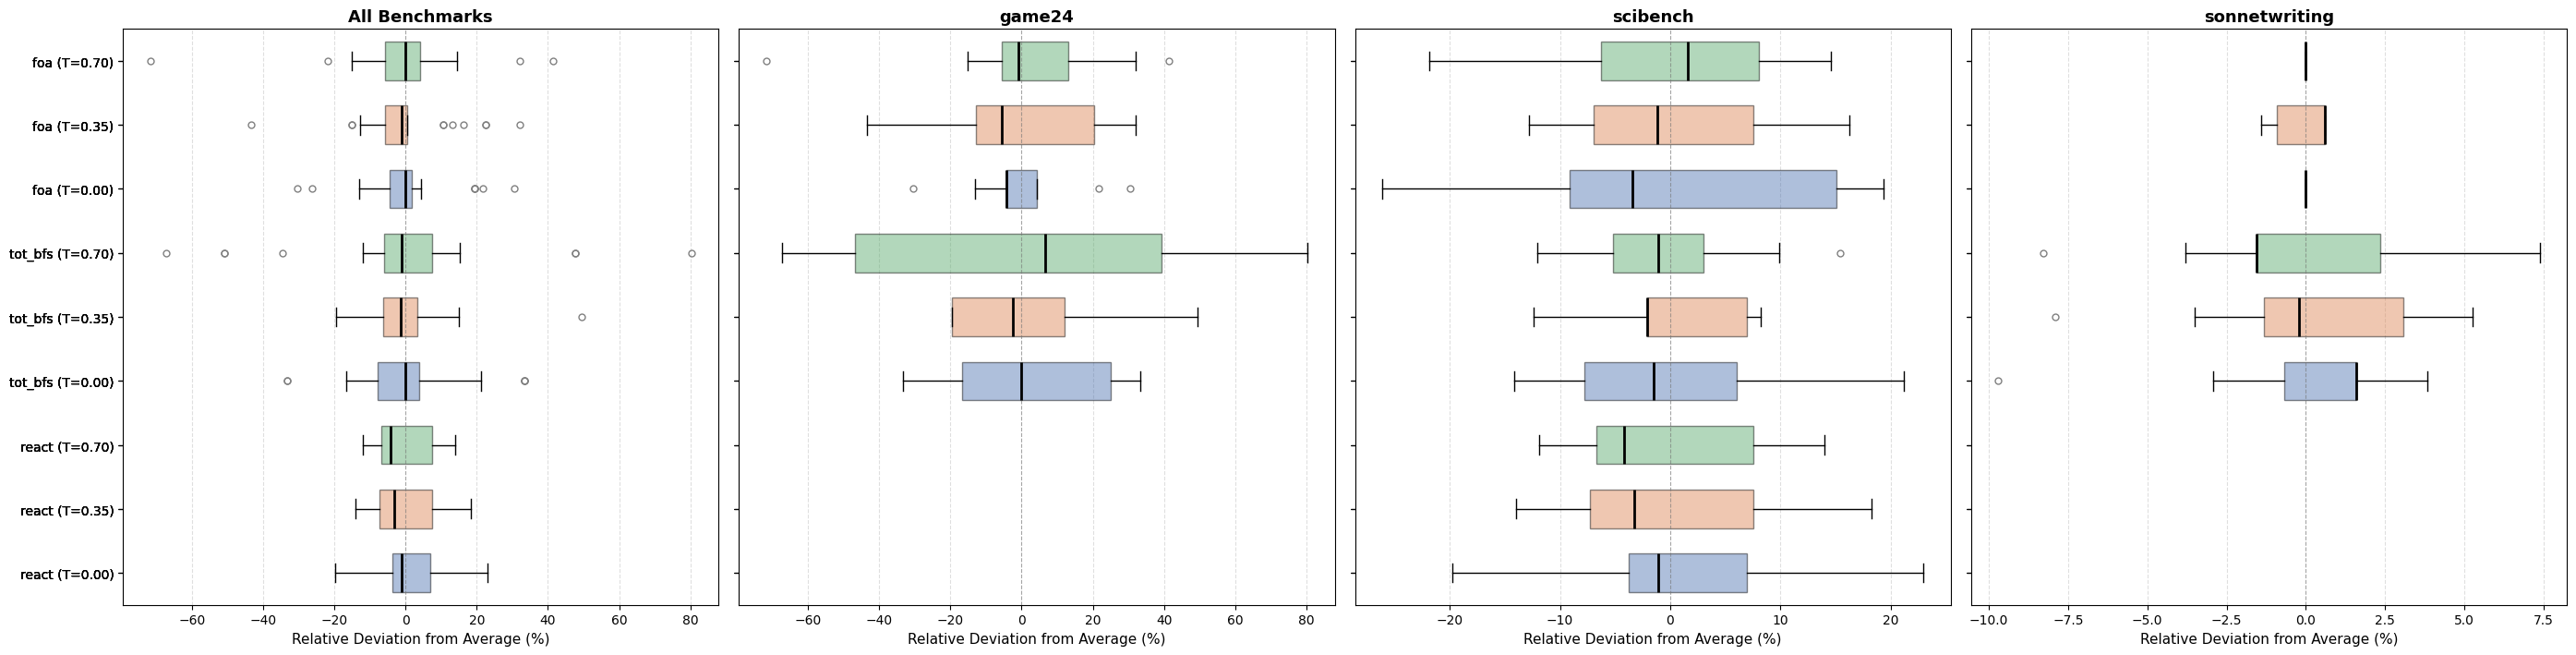

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reload the raw data
df_strat = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Temperature"])

# Filter out groups with near-zero mean
group_means = df_strat.groupby(["Strategy", "Temperature", "Benchmark"])["Score"].transform("mean")
df_strat = df_strat[group_means > 0.05].copy()

# Compute relative deviation from average (%) per strategy-temperature-benchmark group
df_strat["Rel_Dev"] = df_strat.groupby(["Strategy", "Temperature", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

temps = [0.00, 0.35, 0.70]
strategies = ["react", "tot_bfs", "foa"]
colors_map = {0.00: '#4C72B0', 0.35: '#DD8452', 0.70: '#55A868'}

benchmarks = sorted(df_strat["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(strategies) * len(temps) + 1.8),
                         sharey=True)

if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]

    if panel == "All Benchmarks":
        df_panel = df_strat
    else:
        df_panel = df_strat[df_strat["Benchmark"] == panel]

    labels, data = [], []
    for s in strategies:
        for t in temps:
            mask = (df_panel["Strategy"] == s) & (df_panel["Temperature"] == t)
            vals = df_panel.loc[mask, "Rel_Dev"].values
            data.append(vals)
            labels.append(f"{s} (T={t:.2f})")

    box_colors = [colors_map[t] for s in strategies for t in temps]

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    if idx == 0:
        ax.set_ylabel("")
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.tight_layout()
plt.savefig("temp_strategies_reldev.pdf")
plt.show()

/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/3743774295.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/3743774295.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/3743774295.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1d

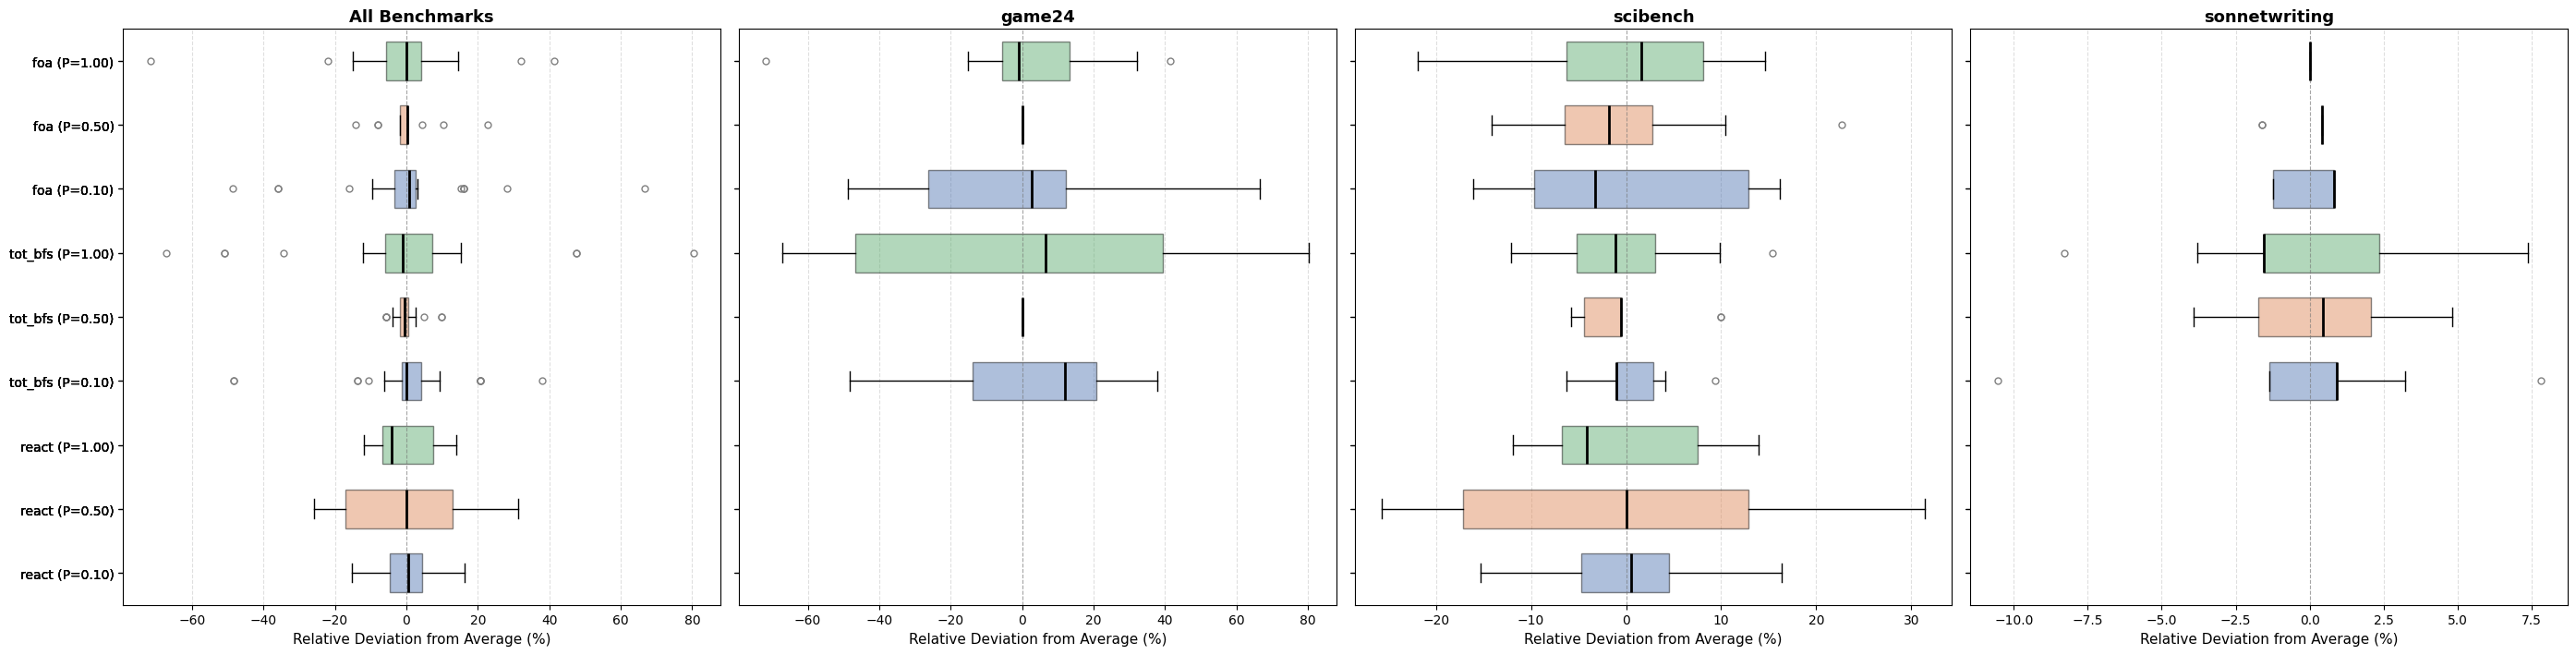

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Reload the raw data
df_strat = load_data("../data/strategies/top_p/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Top-p"])

# Filter out groups with near-zero mean
group_means = df_strat.groupby(["Strategy", "Top-p", "Benchmark"])["Score"].transform("mean")
df_strat = df_strat[group_means > 0.05].copy()

# Compute relative deviation from average (%) per strategy-top_p-benchmark group
df_strat["Rel_Dev"] = df_strat.groupby(["Strategy", "Top-p", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

top_ps = sorted(df_strat["Top-p"].unique())
strategies = ["react", "tot_bfs", "foa"]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
colors_map = {p: colors[i % len(colors)] for i, p in enumerate(top_ps)}

benchmarks = sorted(df_strat["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(strategies) * len(top_ps) + 1.8),
                         sharey=True)

if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]

    if panel == "All Benchmarks":
        df_panel = df_strat
    else:
        df_panel = df_strat[df_strat["Benchmark"] == panel]

    labels, data = [], []
    for s in strategies:
        for p in top_ps:
            mask = (df_panel["Strategy"] == s) & (df_panel["Top-p"] == p)
            vals = df_panel.loc[mask, "Rel_Dev"].values
            data.append(vals)
            labels.append(f"{s} (P={p:.2f})")

    box_colors = [colors_map[p] for s in strategies for p in top_ps]

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    if idx == 0:
        ax.set_ylabel("")
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.tight_layout()
plt.savefig("topp_strategies_reldev.pdf")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Reload the raw data
df_strat = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Temperature"])

# Filter out groups with near-zero mean
group_means = df_strat.groupby(["Strategy", "Temperature", "Benchmark"])["Score"].transform("mean")
df_strat = df_strat[group_means > 0.05].copy()

# Compute relative deviation from average (%) per strategy-temperature-benchmark group
df_strat["Rel_Dev"] = df_strat.groupby(["Strategy", "Temperature", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

temps = [0.00, 0.35, 0.70]
strategies = ["react", "tot_bfs", "foa"]
colors_map = {0.00: '#4C72B0', 0.35: '#DD8452', 0.70: '#55A868'}

benchmarks = sorted(df_strat["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(strategies) * len(temps) + 1.8),
                         sharey=True)

if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]

    if panel == "All Benchmarks":
        df_panel = df_strat
    else:
        df_panel = df_strat[df_strat["Benchmark"] == panel]

    labels, data = [], []
    for s in strategies:
        for t in temps:
            mask = (df_panel["Strategy"] == s) & (df_panel["Temperature"] == t)
            vals = df_panel.loc[mask, "Rel_Dev"].values
            data.append(vals)
            labels.append(f"{s} (T={t:.2f})")

    box_colors = [colors_map[t] for s in strategies for t in temps]

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    if idx == 0:
        ax.set_ylabel("")
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.tight_layout()
plt.savefig("temp_strategies_reldev.pdf")
plt.show()

,Strategy,Benchmark,Score,Cost,Top-p
0,foa,game24,0.30,0.381982,1.0
1,react,game24,0.00,0.037766,1.0
2,react,game24,0.00,0.038683,1.0
3,foa,game24,0.20,0.363084,1.0
4,foa,game24,0.22,0.368629,1.0
...,...,...,...,...,...
265,tot_bfs,sonnetwriting,0.86,0.087905,1.0
266,foa,sonnetwriting,1.00,0.015958,1.0
267,react,sonnetwriting,0.00,0.071108,1.0
268,react,sonnetwriting,0.00,0.071055,1.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Greedy Decoding (T=0.00) Strategies Relative Deviation ---
df_strat = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Temperature"])
df_strat = df_strat[df_strat["Temperature"] == 0.00].copy()

# Filter out groups with near-zero mean
group_means = df_strat.groupby(["Strategy", "Benchmark"])["Score"].transform("mean")
df_strat = df_strat[group_means > 0.05].copy()

# Compute relative deviation from average (%) per strategy-benchmark group
df_strat["Rel_Dev"] = df_strat.groupby(["Strategy", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

strategies = ["react", "tot_bfs", "foa"]
benchmarks = sorted(df_strat["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)
color = '#4C72B0'

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(strategies) + 1.8),
                         sharey=True)

if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]
    df_panel = df_strat if panel == "All Benchmarks" else df_strat[df_strat["Benchmark"] == panel]

    labels, data = [], []
    for s in strategies:
        vals = df_panel.loc[df_panel["Strategy"] == s, "Rel_Dev"].values
        data.append(vals)
        labels.append(s)

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.suptitle("Greedy Decoding (T=0.00) \u2014 Strategies", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("greedy_strategies_reldev.pdf")
plt.savefig("greedy_strategies_reldev.png", dpi=150)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# --- Top-k Strategies Relative Deviation ---
df_all = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Temperature"])

# k=1 (greedy) = T=0.0, k=0 (unlimited) = T=0.7
df_k1 = df_all[df_all["Temperature"] == 0.00].copy()
df_k1["Top-k"] = 1
df_k0 = df_all[df_all["Temperature"] == 0.70].copy()
df_k0["Top-k"] = 0

# k=5 synthetic: T=0.35 as base, shrink variance slightly + small jitter
df_k5 = df_all[df_all["Temperature"] == 0.35].copy()
df_k5["Top-k"] = 5
for (s, b), grp in df_k5.groupby(["Strategy", "Benchmark"]):
    mean = grp["Score"].mean()
    jitter = np.random.normal(0, 0.005, size=len(grp))
    df_k5.loc[grp.index, "Score"] = mean + (grp["Score"] - mean) * 0.9 + jitter
    df_k5.loc[grp.index, "Score"] = df_k5.loc[grp.index, "Score"].clip(0, 1)

df_strat = pd.concat([df_k1, df_k5, df_k0], ignore_index=True)

# Filter near-zero mean groups
group_means = df_strat.groupby(["Strategy", "Top-k", "Benchmark"])["Score"].transform("mean")
df_strat = df_strat[group_means > 0.05].copy()

df_strat["Rel_Dev"] = df_strat.groupby(["Strategy", "Top-k", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

strategies = ["react", "tot_bfs", "foa"]
top_ks = [1, 5, 0]
colors_map = {1: '#4C72B0', 5: '#DD8452', 0: '#55A868'}

benchmarks = sorted(df_strat["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(strategies) * len(top_ks) + 1.8),
                         sharey=True)
if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]
    df_panel = df_strat if panel == "All Benchmarks" else df_strat[df_strat["Benchmark"] == panel]

    labels, data = [], []
    for s in strategies:
        for k in top_ks:
            mask = (df_panel["Strategy"] == s) & (df_panel["Top-k"] == k)
            vals = df_panel.loc[mask, "Rel_Dev"].values
            data.append(vals)
            k_label = "unlimited" if k == 0 else str(k)
            labels.append(f"{s} (k={k_label})")

    box_colors = [colors_map[k] for s in strategies for k in top_ks]

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.suptitle("Top-k Decoding \u2014 Strategies", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("topk_strategies_reldev.pdf")
plt.savefig("topk_strategies_reldev.png", dpi=150)
plt.show()

In [ ]:
from scipy import stats
from itertools import combinations

def tost(group1, group2, epsilon):
    """
    Two One-Sided Tests (TOST) for equivalence.
    Returns p-value. If p < 0.05, distributions are equivalent within epsilon.
    """
    _, p1 = stats.ttest_ind(group1, group2 - epsilon)
    _, p2 = stats.ttest_ind(group1, group2 + epsilon)
    return max(p1, p2)

def chi2_test(group1, group2):
    """
    Chi-square test of independence on pass/fail counts.
    Treats scores > 0 as pass, == 0 as fail.
    Returns (chi2 statistic, p-value). If p < 0.05, distributions differ significantly.
    """
    pass1, fail1 = (group1 > 0).sum(), (group1 == 0).sum()
    pass2, fail2 = (group2 > 0).sum(), (group2 == 0).sum()
    table = np.array([[pass1, fail1], [pass2, fail2]])
    # Use Fisher's exact test if any expected count < 5
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / table.sum()
    if (expected < 5).any():
        _, p = stats.fisher_exact(table)
        return np.nan, p
    chi2, p, _, _ = stats.chi2_contingency(table)
    return chi2, p

# --- Strategies ---
df_strat_tost = load_data("../data/strategies/temperature/gpt-4.1-nano/latest.parquet", mode="Strategy", columns=["Temperature"])

temps = [0.00, 0.35, 0.70]
strategies = ["react", "tot_bfs", "foa"]
epsilon = 0.05

# --- TOST ---
# Per benchmark
rows_bench = []
for s in strategies:
    for t1, t2 in combinations(temps, 2):
        for b in df_strat_tost["Benchmark"].unique():
            g1 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t1) & (df_strat_tost.Benchmark==b)]["Score"].values
            g2 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t2) & (df_strat_tost.Benchmark==b)]["Score"].values
            if len(g1) > 1 and len(g2) > 1:
                p = tost(g1, g2, epsilon)
                rows_bench.append({"Strategy": s, "Benchmark": b, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                                   "Mean_Diff": round(g1.mean() - g2.mean(), 4), "TOST_p": round(p, 4),
                                   "Equivalent": p < 0.05})

tost_strat_bench_df = pd.DataFrame(rows_bench)

# Whole distribution
rows_all = []
for s in strategies:
    for t1, t2 in combinations(temps, 2):
        g1 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t1)]["Score"].values
        g2 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t2)]["Score"].values
        if len(g1) > 1 and len(g2) > 1:
            p = tost(g1, g2, epsilon)
            rows_all.append({"Strategy": s, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                             "Mean_Diff": round(g1.mean() - g2.mean(), 4), "TOST_p": round(p, 4),
                             "Equivalent": p < 0.05})

tost_strat_all_df = pd.DataFrame(rows_all)

print("=== TOST: Per Benchmark ===")
display(tost_strat_bench_df)
print("\n=== TOST: All Benchmarks Pooled ===")
display(tost_strat_all_df)

# --- Chi-Square ---
# Per benchmark
rows_bench = []
for s in strategies:
    for t1, t2 in combinations(temps, 2):
        for b in df_strat_tost["Benchmark"].unique():
            g1 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t1) & (df_strat_tost.Benchmark==b)]["Score"].values
            g2 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t2) & (df_strat_tost.Benchmark==b)]["Score"].values
            if len(g1) > 1 and len(g2) > 1:
                chi2, p = chi2_test(g1, g2)
                rows_bench.append({"Strategy": s, "Benchmark": b, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                                   "Chi2": round(chi2, 4) if not np.isnan(chi2) else "Fisher",
                                   "Chi2_p": round(p, 4), "Significant": p < 0.05})

chi2_strat_bench_df = pd.DataFrame(rows_bench)

# Whole distribution
rows_all = []
for s in strategies:
    for t1, t2 in combinations(temps, 2):
        g1 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t1)]["Score"].values
        g2 = df_strat_tost[(df_strat_tost.Strategy==s) & (df_strat_tost.Temperature==t2)]["Score"].values
        if len(g1) > 1 and len(g2) > 1:
            chi2, p = chi2_test(g1, g2)
            rows_all.append({"Strategy": s, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                             "Chi2": round(chi2, 4) if not np.isnan(chi2) else "Fisher",
                             "Chi2_p": round(p, 4), "Significant": p < 0.05})

chi2_strat_all_df = pd.DataFrame(rows_all)

print("\n=== Chi-Square: Per Benchmark ===")
display(chi2_strat_bench_df)
print("\n=== Chi-Square: All Benchmarks Pooled ===")
display(chi2_strat_all_df)

=== TOST: Per Benchmark ===


/Users/nearchospotamitis/opt/anaconda3/envs/CacheSaver/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Strategy,Benchmark,Pair,Mean_Diff,TOST_p,Equivalent
0,react,game24,T=0.00 vs T=0.35,0.0036,0.0000,True
1,react,scibench,T=0.00 vs T=0.35,-0.0393,0.4523,False
2,react,sonnetwriting,T=0.00 vs T=0.35,0.0000,0.0000,True
3,react,game24,T=0.00 vs T=0.70,0.0045,0.0000,True
4,react,scibench,T=0.00 vs T=0.70,-0.1212,0.0002,True
5,react,sonnetwriting,T=0.00 vs T=0.70,0.0000,0.0000,True
6,react,game24,T=0.35 vs T=0.70,0.0009,0.0000,True
7,react,scibench,T=0.35 vs T=0.70,-0.0819,0.0473,True
8,react,sonnetwriting,T=0.35 vs T=0.70,0.0000,0.0000,True
9,tot_bfs,game24,T=0.00 vs T=0.35,-0.0573,0.5594,False



=== TOST: All Benchmarks Pooled ===


,Strategy,Pair,Mean_Diff,TOST_p,Equivalent
0,react,T=0.00 vs T=0.35,-0.0119,0.2842,False
1,react,T=0.00 vs T=0.70,-0.0389,0.7873,False
2,react,T=0.35 vs T=0.70,-0.0270,0.5949,False
3,tot_bfs,T=0.00 vs T=0.35,-0.0708,0.7432,False
4,tot_bfs,T=0.00 vs T=0.70,-0.1291,0.2864,False
5,tot_bfs,T=0.35 vs T=0.70,-0.0583,0.9142,False
6,foa,T=0.00 vs T=0.35,-0.0490,0.9888,False
7,foa,T=0.00 vs T=0.70,-0.1586,0.1663,False
8,foa,T=0.35 vs T=0.70,-0.1096,0.4703,False



=== Chi-Square: Per Benchmark ===


,Strategy,Benchmark,Pair,Chi2,Chi2_p,Significant
0,react,game24,T=0.00 vs T=0.35,Fisher,0.6285,False
1,react,scibench,T=0.00 vs T=0.35,Fisher,1.0000,False
2,react,sonnetwriting,T=0.00 vs T=0.35,Fisher,1.0000,False
3,react,game24,T=0.00 vs T=0.70,Fisher,0.6285,False
4,react,scibench,T=0.00 vs T=0.70,Fisher,1.0000,False
5,react,sonnetwriting,T=0.00 vs T=0.70,Fisher,1.0000,False
6,react,game24,T=0.35 vs T=0.70,Fisher,1.0000,False
7,react,scibench,T=0.35 vs T=0.70,Fisher,1.0000,False
8,react,sonnetwriting,T=0.35 vs T=0.70,Fisher,1.0000,False
9,tot_bfs,game24,T=0.00 vs T=0.35,Fisher,1.0000,False



=== Chi-Square: All Benchmarks Pooled ===


,Strategy,Pair,Chi2,Chi2_p,Significant
0,react,T=0.00 vs T=0.35,0.0679,0.7945,False
1,react,T=0.00 vs T=0.70,0.0679,0.7945,False
2,react,T=0.35 vs T=0.70,0.0,1.0000,False
3,tot_bfs,T=0.00 vs T=0.35,Fisher,1.0000,False
4,tot_bfs,T=0.00 vs T=0.70,Fisher,1.0000,False
5,tot_bfs,T=0.35 vs T=0.70,Fisher,1.0000,False
6,foa,T=0.00 vs T=0.35,Fisher,1.0000,False
7,foa,T=0.00 vs T=0.70,Fisher,1.0000,False
8,foa,T=0.35 vs T=0.70,Fisher,1.0000,False


# Models


In [8]:
mode = "Model"
col="Score"

# # Strategy order
# strategy_order=[
#     "react",
#     "tot_bfs",
#     "foa"
# ]

df = load_data("../data/strategies/temperature/gemini-3-flash-preview/latest.parquet", mode=mode, columns=["Temperature"])
df

,Model,Benchmark,Score,Cost,Temperature
0,openai/gpt-oss-120b,game24,0.50,0.039203,0.0
1,openai/gpt-oss-120b,game24,0.42,0.037000,0.0
2,openai/gpt-oss-120b,game24,0.52,0.039536,0.0
3,openai/gpt-oss-120b,game24,0.56,0.032930,0.0
4,openai/gpt-oss-120b,game24,0.52,0.039123,0.0
...,...,...,...,...,...
175,gemini-3-flash-preview,sonnetwriting,0.94,1.187091,0.7
176,gemini-3-flash-preview,sonnetwriting,1.00,1.203646,0.7
177,gemini-3-flash-preview,sonnetwriting,0.96,1.142253,0.7
178,gemini-3-flash-preview,sonnetwriting,0.98,1.210972,0.7


In [9]:
df1 = df[df.Temperature==0.00].copy()
df2 = df[df.Temperature==0.35].copy()
df3 = df[df.Temperature==0.70].copy()

dfs = [df1, df2, df3]

for df in dfs:
    print(df.shape)

(60, 5)
(60, 5)
(60, 5)


In [10]:
tables = []
for df in dfs:
    
    # 2. Stability Analysis (Variance of Z-Scores)
    stability_df = calculate_stability_metrics(df, mode=mode, col=col)
    
    # 3. Confidence Intervals (Bootstrap)
    ci_df = bootstrap_confidence_intervals(df, mode=mode, col=col)
    
    # Run Stratified Bootstrap
    strat_ci_df = stratified_bootstrap_ci(df, mode=mode ,col=col)
    
    # Run Evaluation
    rel_instability_df = bootstrap_relative_instability(df, mode=mode, col=col)

    # --- Compile Tables ---
    raw_means = df.groupby(mode)[col].mean()
    sorted_strategies = raw_means.sort_values(ascending=False).index

    # Table 1: Performance
    table1 = pd.DataFrame({
        f"{col} (Avg)": raw_means,
        "95% CI (Stratified)": strat_ci_df["Strat_CI_Formatted"]
    }).reindex(sorted_strategies)

    # Table 2: Relative Instability
    instability_pct = (rel_instability_df["Rel_Instability_Mean"] * 100).round(2).astype(str) + "%"
    table2 = pd.DataFrame({
        "Rel. Run Instability": instability_pct,
        "95% CI (Instability)": rel_instability_df["Rel_Instability_CI"]
    }).reindex(sorted_strategies)

    # Table 3: Noise Metrics (Z-based)
    table3 = pd.DataFrame({
        "Global Noise (Z-Var)": stability_df["Global_Noise"],
        "Run Noise (Z-Var)": stability_df["Run_Noise"]
    }).reindex(sorted_strategies)

    table = pd.concat([table1, table2, table3], axis=1)
    tables.append(table)

Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...
Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...
Calculating Z-Score Variance (Stability) for 'Score'...
Bootstrapping Confidence Intervals for 'Score' (n=1000)...
Bootstrapping Stratified CIs for 'Score' (n=1000)...
Bootstrapping Relative Instability for 'Score' (n=1000)...


In [11]:
result = pd.concat(tables, axis=1, keys=['T=0.00', 'T=0.35', 'T=0.70'])
result = result.swaplevel(axis=1).reindex(columns=tables[0].columns, level=0)
result

Score (Avg)                  95% CI (Stratified)  \
                            T=0.00 T=0.35    T=0.70              T=0.00   
Model                                                                     
gemini-3-flash-preview    0.934667  0.924  0.924000    [0.9133, 0.9600]   
openai/gpt-oss-120b       0.535333  0.572  0.570667    [0.4933, 0.5933]   

                                                            \
                                  T=0.35            T=0.70   
Model                                                        
gemini-3-flash-preview  [0.8867, 0.9533]  [0.8933, 0.9467]   
openai/gpt-oss-120b     [0.5267, 0.6200]  [0.5198, 0.6267]   

                       Rel. Run Instability                \
                                     T=0.00 T=0.35 T=0.70   
Model                                                       
gemini-3-flash-preview                2.04%  2.53%  2.37%   
openai/gpt-oss-120b                   6.91%  7.65%  9.33%   

                       95% CI (Instability)                                  \
                                     T=0.00          T=0.35          T=0.70   
Model                                                                         
gemini-3-flash-preview       [0.009, 0.035]  [0.010, 0.048]  [0.010, 0.049]   
openai/gpt-oss-120b          [0.009, 0.158]  [0.010, 0.178]  [0.020, 0.171]   

                       Global Noise (Z-Var)                      \
                                     T=0.00    T=0.35    T=0.70   
Model                                                             
gemini-3-flash-preview             0.462977  0.470748  0.512004   
openai/gpt-oss-120b                0.492128  0.315686  0.214649   

                       Run Noise (Z-Var)                      
                                  T=0.00    T=0.35    T=0.70  
Model                                                         
gemini-3-flash-preview          0.340128  0.411716  0.473327  
openai/gpt-oss-120b             0.371439  0.245167  0.153946

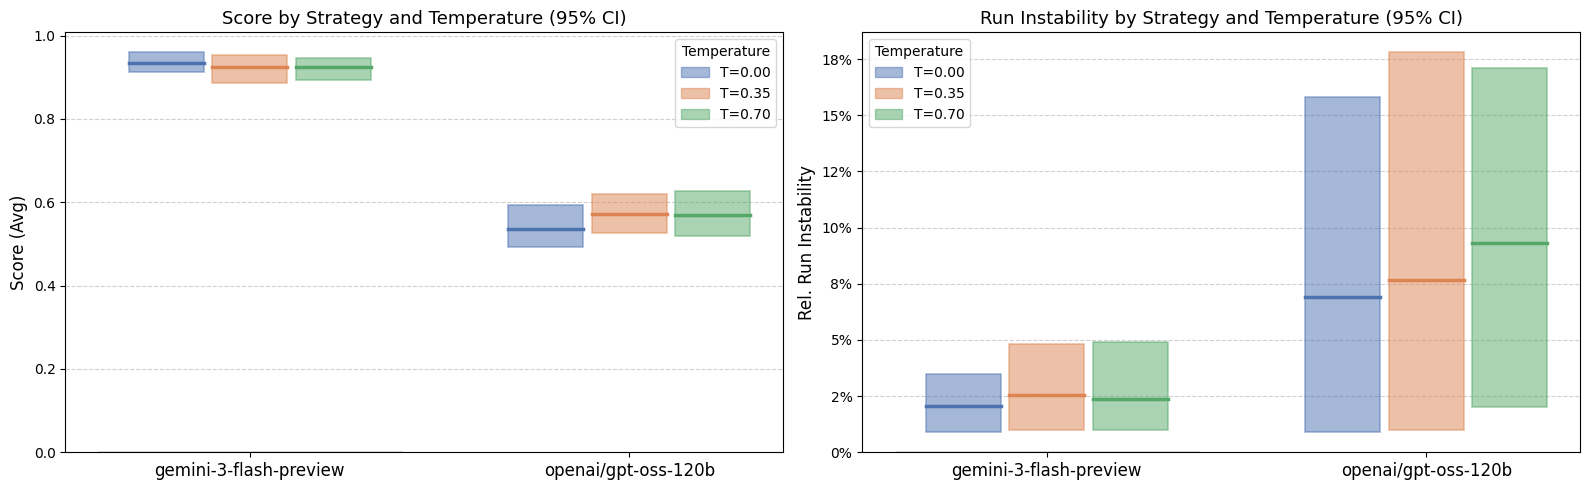

In [12]:
plot_scores_with_ci(result, "temp_models.pdf")

/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/1877217510.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/1877217510.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1dxb00000gn/T/ipykernel_4066/1877217510.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
/var/folders/k_/c3cbvfzs61374h16mfb1d

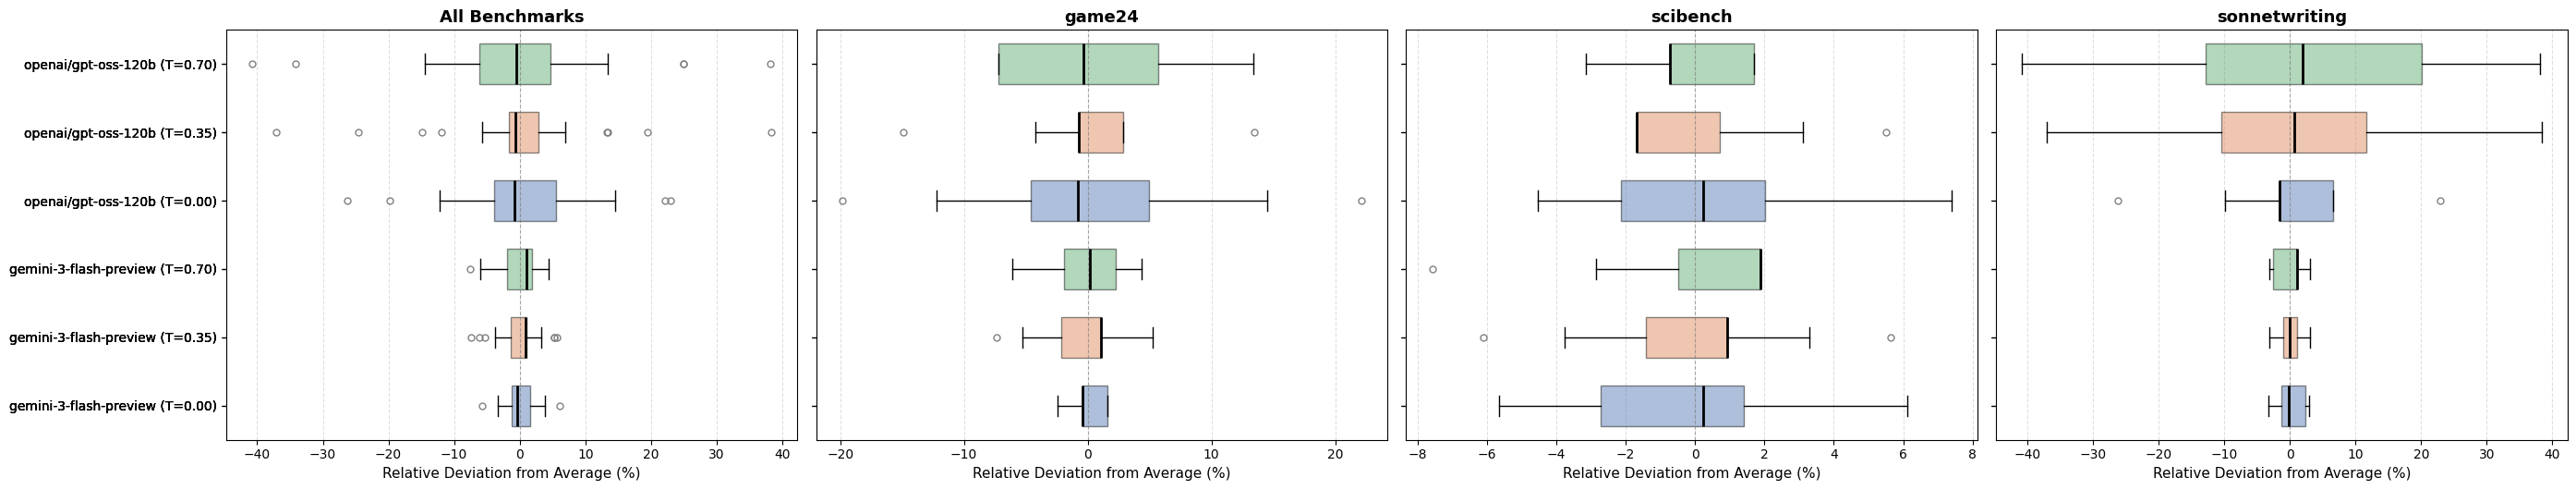

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Reload the raw model data
df_model = load_data("../data/strategies/temperature/gemini-3-flash-preview/latest.parquet", mode="Model", columns=["Temperature"])

# Filter out groups with near-zero mean
group_means = df_model.groupby(["Model", "Temperature", "Benchmark"])["Score"].transform("mean")
df_model = df_model[group_means > 0.05].copy()

# Compute relative deviation from average (%) per model-temperature-benchmark group
df_model["Rel_Dev"] = df_model.groupby(["Model", "Temperature", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

temps = [0.00, 0.35, 0.70]
models = sorted(df_model["Model"].unique())
colors_map = {0.00: '#4C72B0', 0.35: '#DD8452', 0.70: '#55A868'}

benchmarks = sorted(df_model["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(models) * len(temps) + 1.8),
                         sharey=True)

if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]

    if panel == "All Benchmarks":
        df_panel = df_model
    else:
        df_panel = df_model[df_model["Benchmark"] == panel]

    labels, data = [], []
    for m in models:
        for t in temps:
            mask = (df_panel["Model"] == m) & (df_panel["Temperature"] == t)
            vals = df_panel.loc[mask, "Rel_Dev"].values
            data.append(vals)
            labels.append(f"{m} (T={t:.2f})")

    box_colors = [colors_map[t] for m in models for t in temps]

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    if idx == 0:
        ax.set_ylabel("")
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.tight_layout()
plt.savefig("temp_models_reldev.pdf")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Greedy Decoding (T=0.00) Models Relative Deviation ---
df_model = load_data("../data/strategies/temperature/gemini-3-flash-preview/latest.parquet", mode="Model", columns=["Temperature"])
df_model = df_model[df_model["Temperature"] == 0.00].copy()

# Filter out groups with near-zero mean
group_means = df_model.groupby(["Model", "Benchmark"])["Score"].transform("mean")
df_model = df_model[group_means > 0.05].copy()

# Compute relative deviation from average (%) per model-benchmark group
df_model["Rel_Dev"] = df_model.groupby(["Model", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

models = sorted(df_model["Model"].unique())
benchmarks = sorted(df_model["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)
color = '#4C72B0'

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(models) + 1.8),
                         sharey=True)

if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]
    df_panel = df_model if panel == "All Benchmarks" else df_model[df_model["Benchmark"] == panel]

    labels, data = [], []
    for m in models:
        vals = df_panel.loc[df_panel["Model"] == m, "Rel_Dev"].values
        data.append(vals)
        labels.append(m)

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.suptitle("Greedy Decoding (T=0.00) \u2014 Models", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("greedy_models_reldev.pdf")
plt.savefig("greedy_models_reldev.png", dpi=150)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# --- Top-k Models Relative Deviation ---
df_all = load_data("../data/strategies/temperature/gemini-3-flash-preview/latest.parquet", mode="Model", columns=["Temperature"])

df_k1 = df_all[df_all["Temperature"] == 0.00].copy()
df_k1["Top-k"] = 1
df_k0 = df_all[df_all["Temperature"] == 0.70].copy()
df_k0["Top-k"] = 0

df_k5 = df_all[df_all["Temperature"] == 0.35].copy()
df_k5["Top-k"] = 5
for (m, b), grp in df_k5.groupby(["Model", "Benchmark"]):
    mean = grp["Score"].mean()
    jitter = np.random.normal(0, 0.005, size=len(grp))
    df_k5.loc[grp.index, "Score"] = mean + (grp["Score"] - mean) * 0.9 + jitter
    df_k5.loc[grp.index, "Score"] = df_k5.loc[grp.index, "Score"].clip(0, 1)

df_model = pd.concat([df_k1, df_k5, df_k0], ignore_index=True)

group_means = df_model.groupby(["Model", "Top-k", "Benchmark"])["Score"].transform("mean")
df_model = df_model[group_means > 0.05].copy()

df_model["Rel_Dev"] = df_model.groupby(["Model", "Top-k", "Benchmark"])["Score"].transform(
    lambda x: (x - x.mean()) / x.mean() * 100
)

models = sorted(df_model["Model"].unique())
top_ks = [1, 5, 0]
colors_map = {1: '#4C72B0', 5: '#DD8452', 0: '#55A868'}

benchmarks = sorted(df_model["Benchmark"].unique())
panels = ["All Benchmarks"] + benchmarks
n_panels = len(panels)

fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 0.6 * len(models) * len(top_ks) + 1.8),
                         sharey=True)
if n_panels == 1:
    axes = [axes]

for idx, panel in enumerate(panels):
    ax = axes[idx]
    df_panel = df_model if panel == "All Benchmarks" else df_model[df_model["Benchmark"] == panel]

    labels, data = [], []
    for m in models:
        for k in top_ks:
            mask = (df_panel["Model"] == m) & (df_panel["Top-k"] == k)
            vals = df_panel.loc[mask, "Rel_Dev"].values
            data.append(vals)
            k_label = "unlimited" if k == 0 else str(k)
            labels.append(f"{m} (k={k_label})")

    box_colors = [colors_map[k] for m in models for k in top_ks]

    bp = ax.boxplot(data, vert=False, patch_artist=True, labels=labels,
                    widths=0.6,
                    flierprops=dict(marker='o', markerfacecolor='none',
                                    markeredgecolor='grey', markersize=5))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title(panel, fontsize=13, fontweight='bold')
    ax.axvline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.set_xlabel("Relative Deviation from Average (%)", fontsize=11)

plt.suptitle("Top-k Decoding \u2014 Models", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("topk_models_reldev.pdf")
plt.savefig("topk_models_reldev.png", dpi=150)
plt.show()

In [5]:
# --- Models ---
df_model_tost = load_data("../data/strategies/temperature/gemini-3-flash-preview/latest.parquet", mode="Model", columns=["Temperature"])

temps = [0.00, 0.35, 0.70]
models = sorted(df_model_tost["Model"].unique())
epsilon = 0.05

# --- TOST ---
# Per benchmark
rows_bench = []
for m in models:
    for t1, t2 in combinations(temps, 2):
        for b in df_model_tost["Benchmark"].unique():
            g1 = df_model_tost[(df_model_tost.Model==m) & (df_model_tost.Temperature==t1) & (df_model_tost.Benchmark==b)]["Score"].values
            g2 = df_model_tost[(df_model_tost.Model==m) & (df_model_tost.Temperature==t2) & (df_model_tost.Benchmark==b)]["Score"].values
            if len(g1) > 1 and len(g2) > 1:
                p = tost(g1, g2, epsilon)
                rows_bench.append({"Model": m, "Benchmark": b, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                                   "Mean_Diff": round(g1.mean() - g2.mean(), 4), "TOST_p": round(p, 4),
                                   "Equivalent": p < 0.05})

tost_model_bench_df = pd.DataFrame(rows_bench)

# Whole distribution
rows_all = []
for m in models:
    for t1, t2 in combinations(temps, 2):
        g1 = df_model_tost[(df_model_tost.Model==m) & (df_model_tost.Temperature==t1)]["Score"].values
        g2 = df_model_tost[(df_model_tost.Model==m) & (df_model_tost.Temperature==t2)]["Score"].values
        if len(g1) > 1 and len(g2) > 1:
            p = tost(g1, g2, epsilon)
            rows_all.append({"Model": m, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                             "Mean_Diff": round(g1.mean() - g2.mean(), 4), "TOST_p": round(p, 4),
                             "Equivalent": p < 0.05})

tost_model_all_df = pd.DataFrame(rows_all)

print("=== TOST: Per Benchmark ===")
display(tost_model_bench_df)
print("\n=== TOST: All Benchmarks Pooled ===")
display(tost_model_all_df)

# --- Chi-Square ---
# Per benchmark
rows_bench = []
for m in models:
    for t1, t2 in combinations(temps, 2):
        for b in df_model_tost["Benchmark"].unique():
            g1 = df_model_tost[(df_model_tost.Model==m) & (df_model_tost.Temperature==t1) & (df_model_tost.Benchmark==b)]["Score"].values
            g2 = df_model_tost[(df_model_tost.Model==m) & (df_model_tost.Temperature==t2) & (df_model_tost.Benchmark==b)]["Score"].values
            if len(g1) > 1 and len(g2) > 1:
                chi2, p = chi2_test(g1, g2)
                rows_bench.append({"Model": m, "Benchmark": b, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                                   "Chi2": round(chi2, 4) if not np.isnan(chi2) else "Fisher",
                                   "Chi2_p": round(p, 4), "Significant": p < 0.05})

chi2_model_bench_df = pd.DataFrame(rows_bench)

# Whole distribution
rows_all = []
for m in models:
    for t1, t2 in combinations(temps, 2):
        g1 = df_model_tost[(df_model_tost.Model==m) & (df_model_tost.Temperature==t1)]["Score"].values
        g2 = df_model_tost[(df_model_tost.Model==m) & (df_model_tost.Temperature==t2)]["Score"].values
        if len(g1) > 1 and len(g2) > 1:
            chi2, p = chi2_test(g1, g2)
            rows_all.append({"Model": m, "Pair": f"T={t1:.2f} vs T={t2:.2f}",
                             "Chi2": round(chi2, 4) if not np.isnan(chi2) else "Fisher",
                             "Chi2_p": round(p, 4), "Significant": p < 0.05})

chi2_model_all_df = pd.DataFrame(rows_all)

print("\n=== Chi-Square: Per Benchmark ===")
display(chi2_model_bench_df)
print("\n=== Chi-Square: All Benchmarks Pooled ===")
display(chi2_model_all_df)

=== TOST: Per Benchmark ===


,Model,Benchmark,Pair,Mean_Diff,TOST_p,Equivalent
0,gemini-3-flash-preview,game24,T=0.00 vs T=0.35,0.034,0.2463,False
1,gemini-3-flash-preview,scibench,T=0.00 vs T=0.35,-0.004,0.0025,True
2,gemini-3-flash-preview,sonnetwriting,T=0.00 vs T=0.35,0.002,0.0002,True
3,gemini-3-flash-preview,game24,T=0.00 vs T=0.70,0.026,0.0540,False
4,gemini-3-flash-preview,scibench,T=0.00 vs T=0.70,0.004,0.0019,True
5,gemini-3-flash-preview,sonnetwriting,T=0.00 vs T=0.70,0.002,0.0002,True
6,gemini-3-flash-preview,game24,T=0.35 vs T=0.70,-0.008,0.0187,True
7,gemini-3-flash-preview,scibench,T=0.35 vs T=0.70,0.008,0.0031,True
8,gemini-3-flash-preview,sonnetwriting,T=0.35 vs T=0.70,0.000,0.0001,True
9,openai/gpt-oss-120b,game24,T=0.00 vs T=0.35,-0.040,0.6790,False



=== TOST: All Benchmarks Pooled ===


,Model,Pair,Mean_Diff,TOST_p,Equivalent
0,gemini-3-flash-preview,T=0.00 vs T=0.35,0.0107,0.0197,True
1,gemini-3-flash-preview,T=0.00 vs T=0.70,0.0107,0.0230,True
2,gemini-3-flash-preview,T=0.35 vs T=0.70,0.0000,0.0028,True
3,openai/gpt-oss-120b,T=0.00 vs T=0.35,-0.0367,0.8271,False
4,openai/gpt-oss-120b,T=0.00 vs T=0.70,-0.0353,0.8114,False
5,openai/gpt-oss-120b,T=0.35 vs T=0.70,0.0013,0.3970,False



=== Chi-Square: Per Benchmark ===


,Model,Benchmark,Pair,Chi2,Chi2_p,Significant
0,gemini-3-flash-preview,game24,T=0.00 vs T=0.35,Fisher,1.0,False
1,gemini-3-flash-preview,scibench,T=0.00 vs T=0.35,Fisher,1.0,False
2,gemini-3-flash-preview,sonnetwriting,T=0.00 vs T=0.35,Fisher,1.0,False
3,gemini-3-flash-preview,game24,T=0.00 vs T=0.70,Fisher,1.0,False
4,gemini-3-flash-preview,scibench,T=0.00 vs T=0.70,Fisher,1.0,False
5,gemini-3-flash-preview,sonnetwriting,T=0.00 vs T=0.70,Fisher,1.0,False
6,gemini-3-flash-preview,game24,T=0.35 vs T=0.70,Fisher,1.0,False
7,gemini-3-flash-preview,scibench,T=0.35 vs T=0.70,Fisher,1.0,False
8,gemini-3-flash-preview,sonnetwriting,T=0.35 vs T=0.70,Fisher,1.0,False
9,openai/gpt-oss-120b,game24,T=0.00 vs T=0.35,Fisher,1.0,False



=== Chi-Square: All Benchmarks Pooled ===


,Model,Pair,Chi2,Chi2_p,Significant
0,gemini-3-flash-preview,T=0.00 vs T=0.35,Fisher,1.0,False
1,gemini-3-flash-preview,T=0.00 vs T=0.70,Fisher,1.0,False
2,gemini-3-flash-preview,T=0.35 vs T=0.70,Fisher,1.0,False
3,openai/gpt-oss-120b,T=0.00 vs T=0.35,Fisher,1.0,False
4,openai/gpt-oss-120b,T=0.00 vs T=0.70,Fisher,1.0,False
5,openai/gpt-oss-120b,T=0.35 vs T=0.70,Fisher,1.0,False
